# Railway Crossing Safety Analysis: Video-Level Multi-View Graph Tensor

**Complete Pipeline: From Annotation to Pattern Discovery**

---

## Table of Contents

1. [Overview & Methodology](#overview)
2. [Dataset Summary](#dataset)
3. [Phase Annotations](#annotations)
4. [Embedding Extraction](#embeddings)
5. [Video-Level Tensor Construction](#tensor)
6. [Symmetric CPD Decomposition](#cpd)
7. [Results & Interpretation](#results)
8. [Save Results](#save)
9. [Non-Negative CPD Analysis](#nonnegative)

---

## 1. Overview & Methodology {#overview}

### Research Question

**Can we identify railway crossing videos that behave similarly during different times of day, and which behavioral phases show the most variation?**

### Video-Level Analysis

Each **video**, rather than each crossing, is a node in the graph because:

- **Problem**: 35th Cornhusker has 23 videos at different times -> cannot represent with single number
- **Solution**: Treat each video as a node in multi-view graph
- **Result**: Both time-of-day and location patterns can be examined

### Multi-View Graph Tensor Approach

```
Nodes:  31 videos
Views:  3 phases (A: Approach, B: Waiting, C: Clearance)
Edges:  Cosine similarity between video embeddings
Tensor: (3 phases × 31 videos × 31 videos)
```

### Analysis Pipeline

```
Videos (31) 
    ↓
Manual Phase Annotation
    ↓
TimeSformer Embeddings (31 × 3 phases = 93 embeddings)
    ↓
Similarity Matrices (3 × 31 × 31)
    ↓
Symmetric CPD Decomposition
    ↓
Pattern Discovery
```

## 2. Dataset Summary {#dataset}

### Video Distribution

| Crossing | Total Videos | Time Distribution |
|----------|-------------|-------------------|
| **35th Cornhusker** | **23 videos** | 11 off-peak, 6 morning rush, 5 midday, 1 afternoon/evening |
| 27th NE Pkwy | 1 video | 1 off-peak |
| 56 & Old Cheney | 1 video | 1 morning rush |
| NW 12th & Cornhusker | 6 videos | 2 morning rush, 3 midday, 1 afternoon/evening |

### Time-of-Day Categories

- **Off-Peak** (7PM-6AM): 12 videos - Low traffic, darkness/fatigue
- **Morning Rush** (6AM-10AM): 9 videos - School + commute, good visibility
- **Midday** (10AM-3PM): 8 videos - Low traffic, optimal visibility
- **Afternoon/Evening** (3PM-7PM): 2 videos - Commute + evening

### Phase Definitions

1. **Pre-Event:** Normal traffic before warning
2. **Phase A (Approach):** Lights flash -> Gates fully down (~12-15s)
3. **Phase B (Waiting):** Gates down -> Train clears (~147-268s, variable!)
4. **Phase C (Clearance):** Train clears -> Gates fully up (~10-18s)
5. **Post-Event:** Normal traffic after gates raised

**Note:** We analyze phases A, B, C (the constrained event phases)

In [1]:
# Setup
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Paths
DATA_DIR = Path('../data')
ANNOTATIONS_PATH = DATA_DIR / 'phase_annotations.json'
EMBEDDINGS_PATH = DATA_DIR / 'phase_embeddings.pkl'
METADATA_PATH = DATA_DIR / 'phase_embeddings_metadata.json'

## 3. Phase Annotations {#annotations}

All 31 videos were manually annotated with phase timestamps and time-of-day labels.

In [2]:
# Load annotations
with open(ANNOTATIONS_PATH, 'r') as f:
    annotations = json.load(f)

print(f"Total annotated videos: {len(annotations)}")
print("\nAnnotations loaded successfully!")

# Show sample annotation
print("\nExample annotation structure:")
sample = annotations[0]
print(f"\nCrossing: {sample['crossing']}")
print(f"Video: {sample['video_filename']}")
print(f"Time of day: {sample['time_of_day']}")
print("\nPhases:")
for phase_name, phase_data in sample['phases'].items():
    if phase_data:
        print(f"  {phase_name}: {phase_data['duration_sec']}s ({phase_data['description']})")

Total annotated videos: 31

Annotations loaded successfully!

Example annotation structure:

Crossing: 27th and NE Pkwy
Video: 2024-02-10_03-20-40 - Trim 1.mp4
Time of day: off_peak

Phases:
  phase_a_approach: 12s (Lights flashing → Gates fully down)
  phase_b_waiting: 246s (Gates down → Train clears (4:18 = 258 sec))
  phase_c_clearance: 18s (Train clears → Gates fully up (4:36 = 276 sec))
  post_event: 32.1s (Normal traffic after event (video ends at 5:08 = 308.1 sec))


In [3]:
# Analyze annotations

# Time-of-day distribution
time_dist = Counter([a['time_of_day'] for a in annotations])
print("\nTime-of-Day Distribution:")
for time, count in sorted(time_dist.items()):
    print(f"  {time:20s}: {count:2d} videos")

# Crossing distribution
crossing_dist = Counter([a['crossing'] for a in annotations])
print("\nCrossing Distribution:")
for crossing, count in sorted(crossing_dist.items()):
    print(f"  {crossing:30s}: {count:2d} videos")

# Phase availability
phase_availability = {
    'phase_a_approach': 0,
    'phase_b_waiting': 0,
    'phase_c_clearance': 0
}

for a in annotations:
    for phase in phase_availability.keys():
        if a['phases'].get(phase) is not None:
            phase_availability[phase] += 1

print("\nPhase Availability:")
for phase, count in phase_availability.items():
    print(f"  {phase:20s}: {count:2d}/{len(annotations)} videos ({100*count/len(annotations):.1f}%)")


Time-of-Day Distribution:
  afternoon_evening   :  2 videos
  midday              :  8 videos
  morning_rush        :  9 videos
  off_peak            : 12 videos

Crossing Distribution:
  27th and NE Pkwy              :  1 videos
  35th and Cornhusker Hwy       : 23 videos
  56 & Old Cheney               :  1 videos
  NW 12th & Cornhusker          :  6 videos

Phase Availability:
  phase_a_approach    : 28/31 videos (90.3%)
  phase_b_waiting     : 31/31 videos (100.0%)
  phase_c_clearance   : 31/31 videos (100.0%)


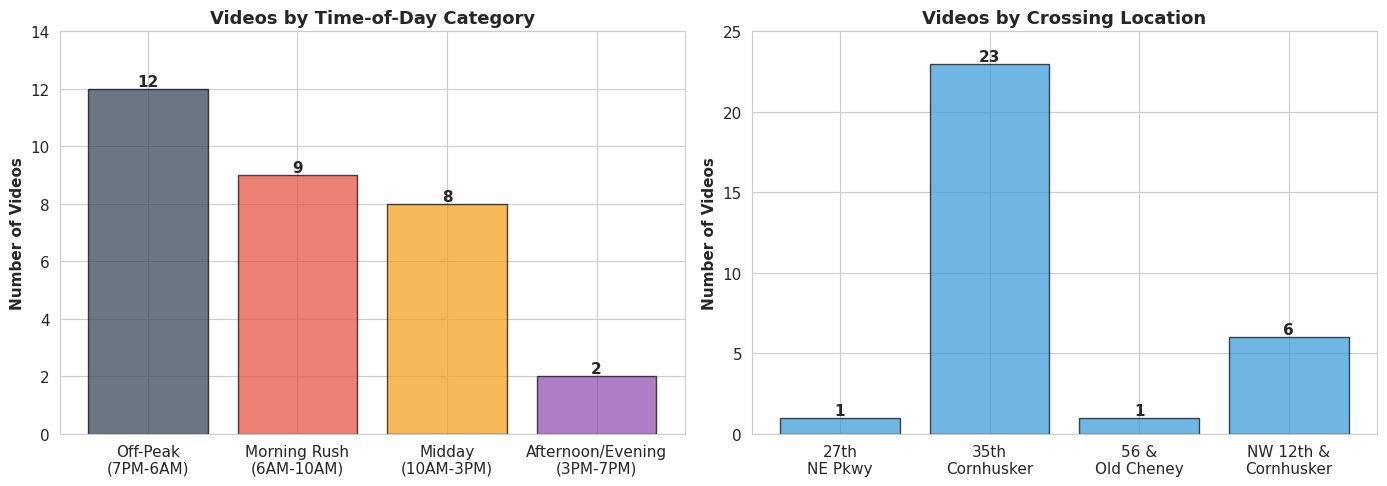


Saved: data/video_distribution.png


In [4]:
# Visualize time-of-day and crossing distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time-of-day
ax1 = axes[0]
time_order = ['off_peak', 'morning_rush', 'midday', 'afternoon_evening']
time_counts = [time_dist[t] for t in time_order]
time_labels = ['Off-Peak\n(7PM-6AM)', 'Morning Rush\n(6AM-10AM)', 
               'Midday\n(10AM-3PM)', 'Afternoon/Evening\n(3PM-7PM)']
colors = ['#2C3E50', '#E74C3C', '#F39C12', '#8E44AD']

bars1 = ax1.bar(time_labels, time_counts, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Number of Videos', fontweight='bold')
ax1.set_title('Videos by Time-of-Day Category', fontweight='bold', fontsize=13)
ax1.set_ylim(0, max(time_counts) + 2)

# Add counts on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Crossings
ax2 = axes[1]
crossing_names = list(crossing_dist.keys())
crossing_counts = [crossing_dist[c] for c in crossing_names]
# Create labels that match the sorted order of crossing_names
crossing_labels = []
for name in crossing_names:
    if '27th' in name:
        crossing_labels.append('27th\nNE Pkwy')
    elif '35th' in name:
        crossing_labels.append('35th\nCornhusker')
    elif '56' in name:
        crossing_labels.append('56 &\nOld Cheney')
    elif 'NW 12th' in name:
        crossing_labels.append('NW 12th &\nCornhusker')
    else:
        crossing_labels.append(name[:15])

bars2 = ax2.bar(crossing_labels, crossing_counts, color='#3498DB', alpha=0.7, edgecolor='black')
ax2.set_ylabel('Number of Videos', fontweight='bold')
ax2.set_title('Videos by Crossing Location', fontweight='bold', fontsize=13)
ax2.set_ylim(0, max(crossing_counts) + 2)

# Add counts on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_DIR / 'video_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: data/video_distribution.png")

## 4. Embedding Extraction {#embeddings}

### Model: TimeSformer

- **Model**: facebook/timesformer-base-finetuned-k400
- **Architecture**: Transformer-based video understanding
- **Output**: 768-dimensional embeddings

### Multi-Clip Sampling Strategy

- Each clip: 8 frames at rate 4 (~1 second at 30fps)
- Clips per phase:
  - < 20 seconds: 1 clip
  - 20-60 seconds: 3 clips
  - \> 60 seconds: 5 clips
- Final embedding = average of all clip embeddings

### Expected Output

- **93 embeddings** = 31 videos × 3 phases (A, B, C)
- Saved to: `data/phase_embeddings.pkl`

In [5]:
# Check if embeddings exist
if EMBEDDINGS_PATH.exists():
    print("Embeddings file found!")
    print(f"  Path: {EMBEDDINGS_PATH}")
    print(f"  Size: {EMBEDDINGS_PATH.stat().st_size / (1024*1024):.2f} MB")
else:
    print("Embeddings not found!")
    print("  Run: python src/extract_phase_embeddings.py")

Embeddings file found!
  Path: ../data/phase_embeddings.pkl
  Size: 0.40 MB


In [6]:
# Load embeddings and metadata
with open(EMBEDDINGS_PATH, 'rb') as f:
    embeddings_raw = pickle.load(f)

with open(METADATA_PATH, 'r') as f:
    metadata_list = json.load(f)

# Count unique videos
unique_videos = set((entry['video_filename'], entry['crossing'], entry['time_of_day']) 
                    for entry in metadata_list)
print(f"Loaded embeddings for {len(unique_videos)} unique videos")
print(f"Total metadata entries: {len(metadata_list)} (includes all phases)")
print(f"\nPhase keys in embeddings: {list(embeddings_raw.keys())}")

# Inspect structure
print("\nEmbedding structure:")
print(f"  Phase A embeddings: {len(embeddings_raw['phase_a_approach'])} entries")
print(f"  Phase B embeddings: {len(embeddings_raw['phase_b_waiting'])} entries")
print(f"  Phase C embeddings: {len(embeddings_raw['phase_c_clearance'])} entries")

# Check sample
import torch
sample_emb = embeddings_raw['phase_a_approach'][0]
if sample_emb is not None:
    if isinstance(sample_emb, torch.Tensor):
        print(f"\nSample embedding type: torch.Tensor")
        print(f"Sample embedding shape: {sample_emb.shape}")
    else:
        print(f"\nSample embedding type: numpy array")
        print(f"Sample embedding shape: {sample_emb.shape}")
else:
    print("\nFirst entry is None (phase not present)")

Loaded embeddings for 31 unique videos
Total metadata entries: 125 (includes all phases)

Phase keys in embeddings: ['pre_event', 'phase_a_approach', 'phase_b_waiting', 'phase_c_clearance', 'post_event']

Embedding structure:
  Phase A embeddings: 31 entries
  Phase B embeddings: 31 entries
  Phase C embeddings: 31 entries

Sample embedding type: torch.Tensor
Sample embedding shape: torch.Size([768])


In [7]:
# Count embeddings per phase
phase_counts = {
    'phase_a_approach': 0,
    'phase_b_waiting': 0,
    'phase_c_clearance': 0
}

for phase_key in phase_counts.keys():
    for emb in embeddings_raw[phase_key]:
        if emb is not None:
            phase_counts[phase_key] += 1

print("\nPhase Embedding Counts:")
total_embeddings = 0
for phase, count in phase_counts.items():
    print(f"  {phase:20s}: {count:2d}/31 videos")
    total_embeddings += count

print(f"\nTotal embeddings: {total_embeddings}")
print(f"Expected: 93 (31 videos × 3 phases, accounting for missing phases)")


Phase Embedding Counts:
  phase_a_approach    : 28/31 videos
  phase_b_waiting     : 31/31 videos
  phase_c_clearance   : 31/31 videos

Total embeddings: 90
Expected: 93 (31 videos × 3 phases, accounting for missing phases)


## 5. Video-Level Tensor Construction {#tensor}

### Goal: Build (3 × 31 × 31) Multi-View Graph Tensor

**Steps:**
1. For each phase (A, B, C):
   - Extract embeddings for all videos that have this phase
   - Compute 31×31 cosine similarity matrix
2. Stack 3 similarity matrices into tensor

**Interpretation:**
- `tensor[0, i, j]` = Similarity between videos i and j during Phase A (Approach)
- `tensor[1, i, j]` = Similarity between videos i and j during Phase B (Waiting)
- `tensor[2, i, j]` = Similarity between videos i and j during Phase C (Clearance)

In [8]:
# Build video metadata from metadata_list (deduplicate by video)
# Create a mapping from video to its metadata
video_to_metadata = {}
for entry in metadata_list:
    video_key = entry['video_filename']
    if video_key not in video_to_metadata:
        video_to_metadata[video_key] = {
            'filename': entry['video_filename'],
            'crossing': entry['crossing'],
            'time_of_day': entry['time_of_day']
        }

# Create ordered list matching embedding order
video_metadata = list(video_to_metadata.values())

n_videos = len(video_metadata)
print(f"Building tensor for {n_videos} videos")
print(f"Target shape: (3 phases × {n_videos} videos × {n_videos} videos)")

# Show first few videos
print(f"\nFirst 3 videos:")
for i, v in enumerate(video_metadata[:3]):
    print(f"  {i}: [{v['time_of_day']:15s}] {v['crossing']}")

Building tensor for 31 videos
Target shape: (3 phases × 31 videos × 31 videos)

First 3 videos:
  0: [off_peak       ] 27th and NE Pkwy
  1: [afternoon_evening] 35th and Cornhusker Hwy
  2: [off_peak       ] 35th and Cornhusker Hwy


In [9]:
# Extract embeddings for each phase and convert to numpy
import torch

phase_embeddings = {
    'phase_a_approach': [],
    'phase_b_waiting': [],
    'phase_c_clearance': []
}

# Collect embeddings (convert torch tensors to numpy)
for phase_key in phase_embeddings.keys():
    for emb in embeddings_raw[phase_key]:
        if emb is not None:
            # Convert torch tensor to numpy if needed
            if isinstance(emb, torch.Tensor):
                phase_embeddings[phase_key].append(emb.cpu().numpy())
            else:
                phase_embeddings[phase_key].append(emb)
        else:
            # Missing phase: use zero vector
            phase_embeddings[phase_key].append(np.zeros(768))

# Convert to numpy arrays
for phase_key in phase_embeddings.keys():
    phase_embeddings[phase_key] = np.array(phase_embeddings[phase_key])
    print(f"{phase_key:20s}: {phase_embeddings[phase_key].shape}")
    
print(f"\nAll embeddings converted to numpy arrays")

phase_a_approach    : (31, 768)
phase_b_waiting     : (31, 768)
phase_c_clearance   : (31, 768)

All embeddings converted to numpy arrays


In [10]:
# Build similarity matrices
similarity_matrices = {}

for phase_key, embeddings_array in phase_embeddings.items():
    print(f"\nComputing similarity matrix for {phase_key}...")
    
    # Compute cosine similarity
    sim_matrix = cosine_similarity(embeddings_array)
    
    print(f"  Shape: {sim_matrix.shape}")
    print(f"  Min: {sim_matrix.min():.3f}")
    print(f"  Max: {sim_matrix.max():.3f}")
    print(f"  Mean: {sim_matrix.mean():.3f}")
    
    similarity_matrices[phase_key] = sim_matrix

print("\nSimilarity matrices computed!")


Computing similarity matrix for phase_a_approach...
  Shape: (31, 31)
  Min: 0.000
  Max: 1.000
  Mean: 0.586

Computing similarity matrix for phase_b_waiting...
  Shape: (31, 31)
  Min: 0.294
  Max: 1.000
  Mean: 0.677

Computing similarity matrix for phase_c_clearance...
  Shape: (31, 31)
  Min: 0.233
  Max: 1.000
  Mean: 0.705

Similarity matrices computed!


In [11]:
# Stack into tensor
tensor = np.stack([
    similarity_matrices['phase_a_approach'],
    similarity_matrices['phase_b_waiting'],
    similarity_matrices['phase_c_clearance']
])

print(f"Multi-view graph tensor shape: {tensor.shape}")
print(f"\nInterpretation:")
print(f"  Dimension 0 (size {tensor.shape[0]}): 3 phases (views)")
print(f"  Dimension 1 (size {tensor.shape[1]}): {n_videos} videos (nodes)")
print(f"  Dimension 2 (size {tensor.shape[2]}): {n_videos} videos (nodes)")
print(f"\nTensor constructed successfully!")

Multi-view graph tensor shape: (3, 31, 31)

Interpretation:
  Dimension 0 (size 3): 3 phases (views)
  Dimension 1 (size 31): 31 videos (nodes)
  Dimension 2 (size 31): 31 videos (nodes)

Tensor constructed successfully!


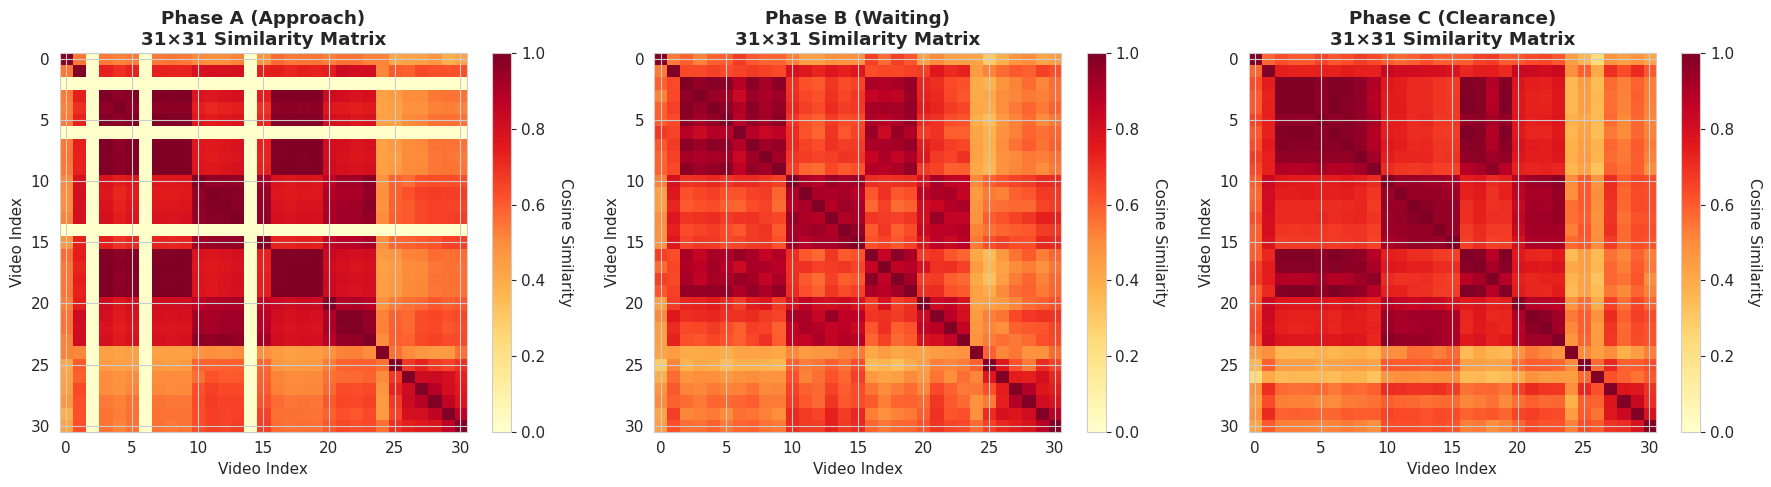


Saved: data/similarity_matrices_31x31.png


In [12]:
# Visualize similarity matrices

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phase_names = ['Phase A (Approach)', 'Phase B (Waiting)', 'Phase C (Clearance)']
phase_keys = ['phase_a_approach', 'phase_b_waiting', 'phase_c_clearance']

for idx, (ax, phase_name, phase_key) in enumerate(zip(axes, phase_names, phase_keys)):
    sim_matrix = similarity_matrices[phase_key]
    
    im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    ax.set_title(f'{phase_name}\n31×31 Similarity Matrix', fontweight='bold')
    ax.set_xlabel('Video Index')
    ax.set_ylabel('Video Index')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig(DATA_DIR / 'similarity_matrices_31x31.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: data/similarity_matrices_31x31.png")

## 6. Symmetric CPD Decomposition {#cpd}

### Goal: Discover Latent Patterns

**Symmetric CPD decomposes the tensor into:**
- **U**: (31 videos × R components) - Video loadings
- **lambdas**: (3 phases × R components) - Phase importances

**We'll try R = 2, 3, 4 components**

In [13]:
# Import CPD implementation
import sys
sys.path.append('../src')
from tensor import SymCPD, train

print("SymCPD and train function imported successfully")

SymCPD and train function imported successfully


In [14]:
# Create dataset and config classes for training
class TensorDataset:
    def __init__(self, tensor_np):
        self.ttensor = torch.from_numpy(tensor_np).float()
        self.num_crossings = tensor_np.shape[1]  # Number of videos
        self.num_timesteps = tensor_np.shape[0]  # Number of phases

class Config:
    def __init__(self, rank, lr=0.01, wd=0.0001, niter=2000):
        self.rank = rank
        self.lr = lr
        self.wd = wd
        self.niter = niter

# Prepare dataset
dataset = TensorDataset(tensor)
print(f"Dataset prepared:")
print(f"  num_crossings (videos): {dataset.num_crossings}")
print(f"  num_timesteps (phases): {dataset.num_timesteps}")
print(f"  Tensor shape: {dataset.ttensor.shape}")

# Set random seed for reproducibility
RANDOM_SEED = 42
print(f"\nUsing random seed: {RANDOM_SEED} for reproducibility")

# Run CPD for different ranks
results = {}

for rank in [2, 3, 4]:
    print(f"\n{'='*70}")
    print(f"Running Symmetric CPD with rank={rank} (5 runs, selecting best)")
    print(f"{'='*70}")
    
    # Run 5 times with different seeds, keep best
    best_loss = float('inf')
    best_model = None
    best_U = None
    best_lambdas = None
    all_losses = []
    
    for seed_offset in range(5):
        seed = RANDOM_SEED + seed_offset
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        print(f"\n  Run {seed_offset + 1}/5 (seed={seed})...", end=' ')
        
        config = Config(rank=rank, lr=0.01, wd=0.0001, niter=2000)
        model = train(dataset, config, verbose=False)
        
        final_loss = model.loss_history[-1]
        all_losses.append(final_loss)
        print(f"Final loss: {final_loss:.4f}")
        
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
            # Extract factors
            with torch.no_grad():
                best_U = model.A.weight.cpu().numpy()
                best_lambdas = model.C.weight.cpu().numpy()
    
    print(f"\n  Best run: loss = {best_loss:.4f}")
    print(f"  Loss range: [{min(all_losses):.4f}, {max(all_losses):.4f}]")
    print(f"  Loss std: {np.std(all_losses):.4f}")
    
    results[rank] = {
        'U': best_U,
        'lambdas': best_lambdas,
        'model': best_model,
        'all_losses': all_losses
    }
    
    print(f"\nRank {rank} complete (best of 5 runs)")
    print(f"  U shape: {best_U.shape}")
    print(f"  lambdas shape: {best_lambdas.shape}")
    print(f"  Final loss: {best_loss:.4f}")

print("\n" + "="*70)
print("All CPD decompositions complete!")
print("="*70)
print("\nNote: Each rank was trained 5 times with different random seeds.")
print("      The model with lowest reconstruction error was selected.")
print(f"      Base random seed: {RANDOM_SEED} (for reproducibility)")

Dataset prepared:
  num_crossings (videos): 31
  num_timesteps (phases): 3
  Tensor shape: torch.Size([3, 31, 31])

Using random seed: 42 for reproducibility

Running Symmetric CPD with rank=2 (5 runs, selecting best)

  Run 1/5 (seed=42)... Final loss: 78.6133

  Run 2/5 (seed=43)... Final loss: 106.7633

  Run 3/5 (seed=44)... Final loss: 106.8437

  Run 4/5 (seed=45)... Final loss: 106.7751

  Run 5/5 (seed=46)... Final loss: 80.2624

  Best run: loss = 78.6133
  Loss range: [78.6133, 106.8437]
  Loss std: 13.4119

Rank 2 complete (best of 5 runs)
  U shape: (31, 2)
  lambdas shape: (3, 2)
  Final loss: 78.6133

Running Symmetric CPD with rank=3 (5 runs, selecting best)

  Run 1/5 (seed=42)... Final loss: 42.9295

  Run 2/5 (seed=43)... Final loss: 42.4554

  Run 3/5 (seed=44)... Final loss: 42.6899

  Run 4/5 (seed=45)... Final loss: 42.6602

  Run 5/5 (seed=46)... Final loss: 21.1198

  Best run: loss = 21.1198
  Loss range: [21.1198, 42.9295]
  Loss std: 8.6269

Rank 3 complete (

In [15]:
# Compare with Non-Negative CPD
print("\n" + "="*70)
print("COMPARISON: Running Non-Negative CPD")
print("="*70)

# Import the new function
from tensor import NonNegativeSymCPD, train_nonnegative

# Run non-negative CPD for rank 3
results_nn = {}

for rank in [2, 3, 4]:  # Run for all ranks to match standard CPD
    print(f"\n{'='*70}")
    print(f"Running Non-Negative CPD with rank={rank} (5 runs, selecting best)")
    print(f"{'='*70}")
    
    # Run 5 times with different seeds, keep best
    best_loss = float('inf')
    best_model = None
    best_U = None
    best_lambdas = None
    all_losses = []
    
    for seed_offset in range(5):
        seed = RANDOM_SEED + seed_offset
        
        print(f"\n  Run {seed_offset + 1}/5 (seed={seed})...", end=' ')
        
        # Create config with seed
        config = Config(rank=rank, lr=0.01, wd=0.0001, niter=2000)
        config.seed = seed
        
        model = train_nonnegative(dataset, config, verbose=False)
        
        final_loss = model.loss_history[-1]
        all_losses.append(final_loss)
        print(f"Final loss: {final_loss:.4f}")
        
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
            best_U = model.A
            best_lambdas = model.C
    
    print(f"\n  Best run: loss = {best_loss:.4f}")
    print(f"  Loss range: [{min(all_losses):.4f}, {max(all_losses):.4f}]")
    print(f"  Loss std: {np.std(all_losses):.4f}")
    
    results_nn[rank] = {
        'U': best_U,
        'lambdas': best_lambdas,
        'model': best_model,
        'all_losses': all_losses
    }
    
    print(f"\nNon-negative Rank {rank} complete (best of 5 runs)")
    print(f"  U shape: {best_U.shape}")
    print(f"  lambdas shape: {best_lambdas.shape}")
    print(f"  Final loss: {best_loss:.4f}")

print("\n" + "="*70)
print("Non-negative CPD complete!")
print("="*70)
print(f"\nComparison with standard CPD (Rank 3):")
print(f"  Standard CPD loss:      {results[3]['model'].loss_history[-1]:.4f}")
print(f"  Non-negative CPD loss:  {results_nn[3]['model'].loss_history[-1]:.4f}")
print(f"\nNote: All loadings in non-negative CPD are ≥ 0 for easier interpretation.")


COMPARISON: Running Non-Negative CPD

Running Non-Negative CPD with rank=2 (5 runs, selecting best)

  Run 1/5 (seed=42)... Final loss: 42.7412

  Run 2/5 (seed=43)... Final loss: 42.7296

  Run 3/5 (seed=44)... Final loss: 42.7210

  Run 4/5 (seed=45)... Final loss: 42.7240

  Run 5/5 (seed=46)... Final loss: 42.7226

  Best run: loss = 42.7210
  Loss range: [42.7210, 42.7412]
  Loss std: 0.0073

Non-negative Rank 2 complete (best of 5 runs)
  U shape: (31, 2)
  lambdas shape: (3, 2)
  Final loss: 42.7210

Running Non-Negative CPD with rank=3 (5 runs, selecting best)

  Run 1/5 (seed=42)... Final loss: 16.6402

  Run 2/5 (seed=43)... Final loss: 16.6573

  Run 3/5 (seed=44)... Final loss: 16.6272

  Run 4/5 (seed=45)... Final loss: 16.6384

  Run 5/5 (seed=46)... Final loss: 16.6456

  Best run: loss = 16.6272
  Loss range: [16.6272, 16.6573]
  Loss std: 0.0098

Non-negative Rank 3 complete (best of 5 runs)
  U shape: (31, 3)
  lambdas shape: (3, 3)
  Final loss: 16.6272

Running Non

## 7. Results & Interpretation {#results}

### Research Questions

1. **Time-of-day patterns**: Do morning rush videos cluster together?
2. **Crossing-specific patterns**: Does NW 12th show unique behavior?
3. **Phase insights**: Which phase shows most variation?

### Analysis Strategy

- **U matrix**: Component loadings for each video
- **lambdas matrix**: Phase importance for each component
- **Color videos by time-of-day** to see temporal patterns
- **Color videos by crossing** to see location-specific patterns

In [16]:
# Create label arrays
time_labels = [v['time_of_day'] for v in video_metadata]
crossing_labels = [v['crossing'] for v in video_metadata]

# Create color maps
time_color_map = {
    'off_peak': '#2C3E50',
    'morning_rush': '#E74C3C',
    'midday': '#F39C12',
    'afternoon_evening': '#8E44AD'
}

crossing_color_map = {
    '35th and Cornhusker Hwy': '#3498DB',
    '27th and NE Pkwy': '#2ECC71',
    '56 & Old Cheney': '#E67E22',
    'NW 12th & Cornhusker': '#9B59B6'
}

time_colors = [time_color_map[t] for t in time_labels]
crossing_colors = [crossing_color_map[c] for c in crossing_labels]

print("Label arrays created")

Label arrays created


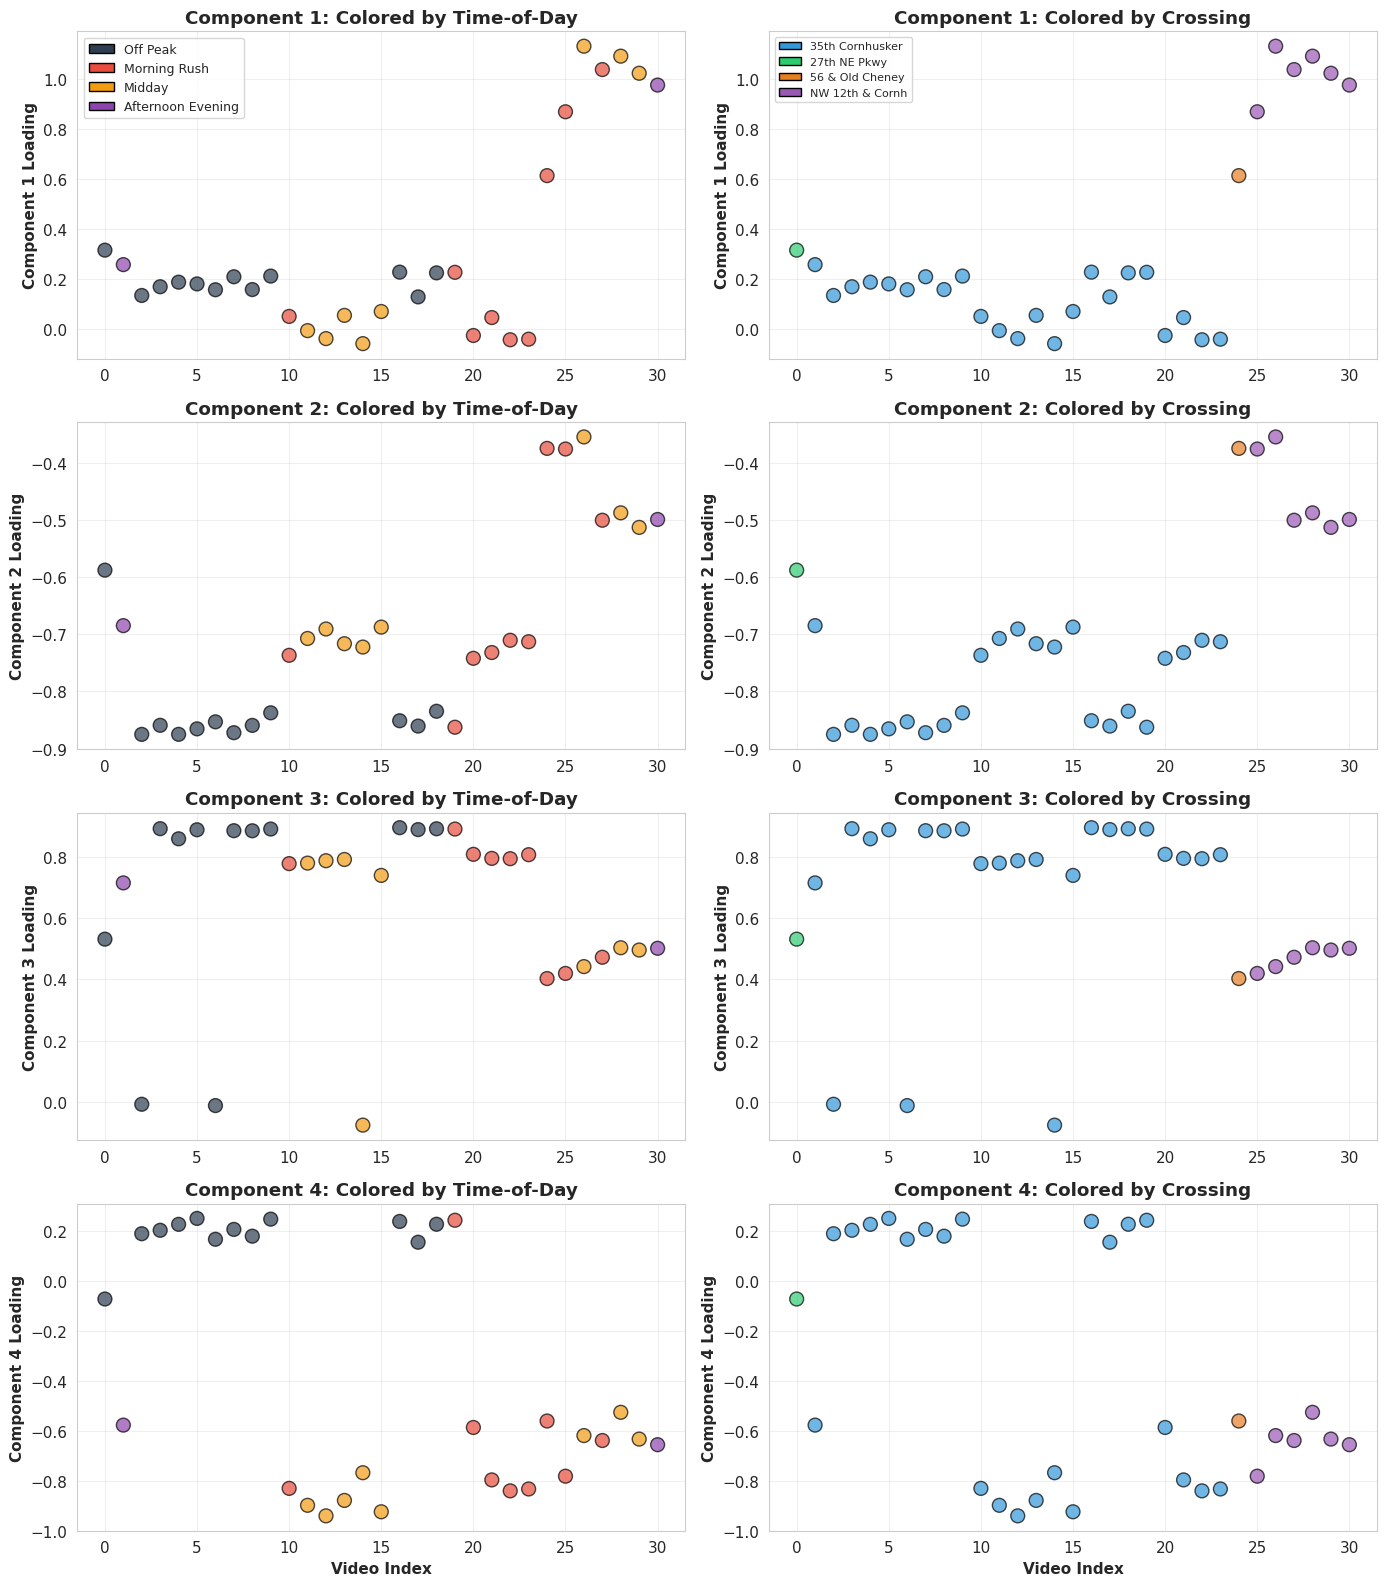


Saved: data/cpd_components_rank4.png


In [17]:
# Visualize CPD components (Rank 4)
rank = 4
U = results[rank]['U']
lambdas = results[rank]['lambdas']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for comp_idx in range(rank):
    # Left column: Color by time-of-day
    ax_left = axes[comp_idx, 0]
    ax_left.scatter(range(n_videos), U[:, comp_idx], 
                   c=time_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
    ax_left.set_ylabel(f'Component {comp_idx+1} Loading', fontweight='bold')
    ax_left.set_title(f'Component {comp_idx+1}: Colored by Time-of-Day', fontweight='bold')
    ax_left.grid(True, alpha=0.3)
    
    if comp_idx == rank - 1:
        ax_left.set_xlabel('Video Index', fontweight='bold')
    
    # Add legend for first row - positioned outside plot area
    if comp_idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, edgecolor='black', label=label.replace('_', ' ').title())
                          for label, color in time_color_map.items()]
        ax_left.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), fontsize=9)
    
    # Right column: Color by crossing
    ax_right = axes[comp_idx, 1]
    ax_right.scatter(range(n_videos), U[:, comp_idx],
                    c=crossing_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
    ax_right.set_ylabel(f'Component {comp_idx+1} Loading', fontweight='bold')
    ax_right.set_title(f'Component {comp_idx+1}: Colored by Crossing', fontweight='bold')
    ax_right.grid(True, alpha=0.3)
    
    if comp_idx == rank - 1:
        ax_right.set_xlabel('Video Index', fontweight='bold')
    
    # Add legend for first row - positioned outside plot area
    if comp_idx == 0:
        legend_elements = [Patch(facecolor=color, edgecolor='black', 
                                label=label.replace('and ', '').replace('Hwy', '').strip()[:15])
                          for label, color in crossing_color_map.items()]
        ax_right.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'cpd_components_rank4.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: data/cpd_components_rank4.png")

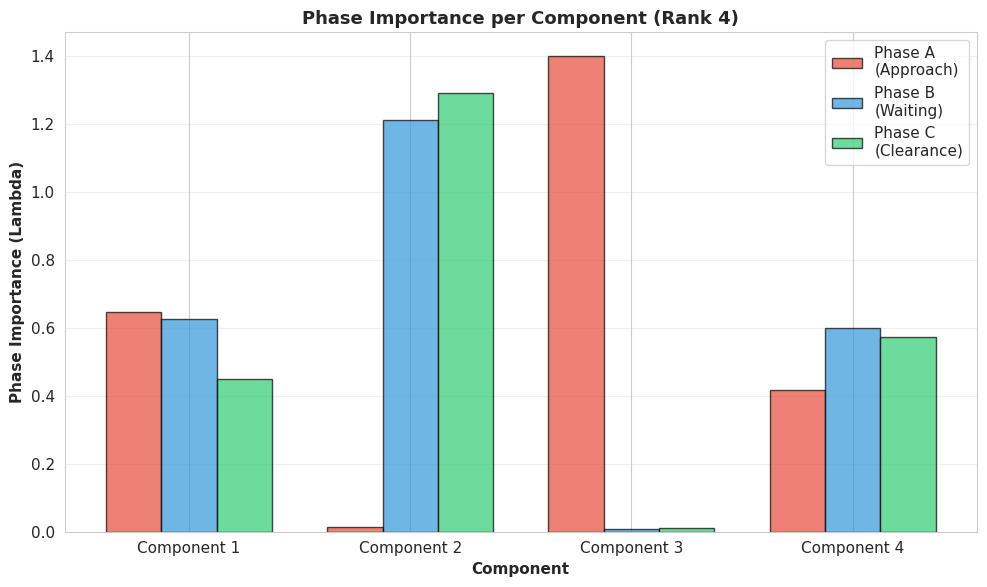


Saved: data/phase_importance_rank4.png


In [18]:
# Analyze phase importance (lambdas)
rank = 4
lambdas = results[rank]['lambdas']

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(rank)
width = 0.25
phase_names_short = ['Phase A\n(Approach)', 'Phase B\n(Waiting)', 'Phase C\n(Clearance)']
colors_phases = ['#E74C3C', '#3498DB', '#2ECC71']

for phase_idx, (phase_name, color) in enumerate(zip(phase_names_short, colors_phases)):
    offset = width * (phase_idx - 1)
    ax.bar(x + offset, lambdas[phase_idx, :], width, 
           label=phase_name, color=color, alpha=0.7, edgecolor='black')

ax.set_ylabel('Phase Importance (Lambda)', fontweight='bold')
ax.set_xlabel('Component', fontweight='bold')
ax.set_title('Phase Importance per Component (Rank 4)', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'Component {i+1}' for i in range(rank)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DATA_DIR / 'phase_importance_rank4.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: data/phase_importance_rank4.png")

In [19]:
# Print interpretation summary
rank = 4
U = results[rank]['U']
lambdas = results[rank]['lambdas']

print("\n" + "="*70)
print("INTERPRETATION SUMMARY (Rank 4)")
print("="*70)

for comp_idx in range(rank):
    print(f"\nComponent {comp_idx + 1}:")
    print("-" * 40)
    
    # Phase importance
    print("\nPhase Importance:")
    phase_names_simple = ['Phase A (Approach)', 'Phase B (Waiting)', 'Phase C (Clearance)']
    for phase_idx, phase_name in enumerate(phase_names_simple):
        print(f"  {phase_name:25s}: {lambdas[phase_idx, comp_idx]:.3f}")
    
    # Dominant phase
    dominant_phase_idx = np.argmax(lambdas[:, comp_idx])
    print(f"\n  -> Dominant phase: {phase_names_simple[dominant_phase_idx]}")
    
    # Top 5 videos with highest loadings
    top_indices = np.argsort(U[:, comp_idx])[-5:][::-1]
    print(f"\nTop 5 videos with highest loadings:")
    for rank_pos, video_idx in enumerate(top_indices, 1):
        video = video_metadata[video_idx]
        loading = U[video_idx, comp_idx]
        print(f"  {rank_pos}. [{video['time_of_day']:20s}] {video['crossing']:30s} (loading: {loading:.3f})")
    
    # Bottom 5 videos with lowest loadings
    bottom_indices = np.argsort(U[:, comp_idx])[:5]
    print(f"\nBottom 5 videos with lowest loadings:")
    for rank_pos, video_idx in enumerate(bottom_indices, 1):
        video = video_metadata[video_idx]
        loading = U[video_idx, comp_idx]
        print(f"  {rank_pos}. [{video['time_of_day']:20s}] {video['crossing']:30s} (loading: {loading:.3f})")

print("\n" + "="*70)


INTERPRETATION SUMMARY (Rank 4)

Component 1:
----------------------------------------

Phase Importance:
  Phase A (Approach)       : 0.645
  Phase B (Waiting)        : 0.626
  Phase C (Clearance)      : 0.450

  -> Dominant phase: Phase A (Approach)

Top 5 videos with highest loadings:
  1. [midday              ] NW 12th & Cornhusker           (loading: 1.133)
  2. [midday              ] NW 12th & Cornhusker           (loading: 1.093)
  3. [morning_rush        ] NW 12th & Cornhusker           (loading: 1.039)
  4. [midday              ] NW 12th & Cornhusker           (loading: 1.024)
  5. [afternoon_evening   ] NW 12th & Cornhusker           (loading: 0.977)

Bottom 5 videos with lowest loadings:
  1. [midday              ] 35th and Cornhusker Hwy        (loading: -0.059)
  2. [morning_rush        ] 35th and Cornhusker Hwy        (loading: -0.043)
  3. [morning_rush        ] 35th and Cornhusker Hwy        (loading: -0.041)
  4. [midday              ] 35th and Cornhusker Hwy        (

## 8. Save Results {#save}

The CPD results, the tensor, and the similarity matrices are pickled to `data/` for use by `rank_selection.ipynb` and `tsne_cpd_visualization.ipynb`.


In [20]:
# Save results
results_path = DATA_DIR / 'cpd_results_31videos.pkl'
with open(results_path, 'wb') as f:
    pickle.dump({
        'results': results,
        'video_metadata': video_metadata,
        'tensor': tensor,
        'similarity_matrices': similarity_matrices
    }, f)

print(f"Standard CPD results saved to: {results_path}")

# Save non-negative results separately
results_nn_path = DATA_DIR / 'cpd_results_nonnegative_31videos.pkl'
with open(results_nn_path, 'wb') as f:
    pickle.dump({
        'results_nn': results_nn,
        'video_metadata': video_metadata,
        'tensor': tensor,
        'similarity_matrices': similarity_matrices
    }, f)

print(f"Non-negative CPD results saved to: {results_nn_path}")

Standard CPD results saved to: ../data/cpd_results_31videos.pkl
Non-negative CPD results saved to: ../data/cpd_results_nonnegative_31videos.pkl


## Summary

This notebook implements the complete video-level multi-view graph tensor analysis:

1. Loaded 31 manually annotated videos
2. Extracted 93 phase embeddings (31 videos × 3 phases)
3. Built 3×31×31 multi-view graph tensor
4. Applied Symmetric CPD decomposition
5. Discovered latent patterns colored by time-of-day and crossing

**Next steps:**
- Identify which component(s) capture time-of-day effects
- Identify which component(s) capture crossing-specific behaviors
- Flag specific risky videos for expert review
- Develop policy recommendations based on discovered patterns

---

## 9. Non-Negative CPD Analysis {#nonnegative}

### Why Non-Negative CPD?

**Standard CPD** produces factors with both positive and negative values, creating a bipolar structure where interpretation requires understanding relative positions (high vs low, positive vs negative).

**Non-Negative CPD** constrains all factors to be ≥ 0, which:
- Simplifies interpretation (high vs low instead of positive vs negative)
- Aligns with physical meaning (similarity can't be "negative")
- Easier to explain to non-technical stakeholders

### Trade-offs

- **Flexibility**: Standard CPD is more flexible (can fit data better)
- **Interpretability**: Non-negative CPD is easier to interpret
- **Reconstruction error**: Non-negative CPD may have slightly higher error due to constraints

In [21]:
# Import non-negative CPD implementation
from tensor import NonNegativeSymCPD, train_nonnegative

print("Non-negative CPD functions imported successfully")

Non-negative CPD functions imported successfully


In [22]:
# Run non-negative CPD for different ranks
results_nn = {}

for rank in [2, 3, 4]:
    print(f"\n{'='*70}")
    print(f"Running Non-Negative CPD with rank={rank} (5 runs, selecting best)")
    print(f"{'='*70}")
    
    # Run 5 times with different seeds, keep best
    best_loss = float('inf')
    best_model = None
    best_U = None
    best_lambdas = None
    all_losses = []
    
    for seed_offset in range(5):
        seed = RANDOM_SEED + seed_offset
        
        print(f"\n  Run {seed_offset + 1}/5 (seed={seed})...", end=' ')
        
        # Create config with seed
        config = Config(rank=rank, lr=0.01, wd=0.0001, niter=2000)
        config.seed = seed
        
        model = train_nonnegative(dataset, config, verbose=False)
        
        final_loss = model.loss_history[-1]
        all_losses.append(final_loss)
        print(f"Final loss: {final_loss:.4f}")
        
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
            best_U = model.A
            best_lambdas = model.C
    
    print(f"\n  Best run: loss = {best_loss:.4f}")
    print(f"  Loss range: [{min(all_losses):.4f}, {max(all_losses):.4f}]")
    print(f"  Loss std: {np.std(all_losses):.4f}")
    
    results_nn[rank] = {
        'U': best_U,
        'lambdas': best_lambdas,
        'model': best_model,
        'all_losses': all_losses
    }
    
    print(f"\nNon-negative Rank {rank} complete (best of 5 runs)")
    print(f"  U shape: {best_U.shape}")
    print(f"  lambdas shape: {best_lambdas.shape}")
    print(f"  Final loss: {best_loss:.4f}")

print("\n" + "="*70)
print("All Non-Negative CPD decompositions complete!")
print("="*70)
print("\nNote: Each rank was trained 5 times with different random seeds.")
print("      The model with lowest reconstruction error was selected.")
print(f"      Base random seed: {RANDOM_SEED} (for reproducibility)")


Running Non-Negative CPD with rank=2 (5 runs, selecting best)

  Run 1/5 (seed=42)... Final loss: 42.7412

  Run 2/5 (seed=43)... Final loss: 42.7296

  Run 3/5 (seed=44)... Final loss: 42.7210

  Run 4/5 (seed=45)... Final loss: 42.7240

  Run 5/5 (seed=46)... Final loss: 42.7226

  Best run: loss = 42.7210
  Loss range: [42.7210, 42.7412]
  Loss std: 0.0073

Non-negative Rank 2 complete (best of 5 runs)
  U shape: (31, 2)
  lambdas shape: (3, 2)
  Final loss: 42.7210

Running Non-Negative CPD with rank=3 (5 runs, selecting best)

  Run 1/5 (seed=42)... Final loss: 16.6402

  Run 2/5 (seed=43)... Final loss: 16.6573

  Run 3/5 (seed=44)... Final loss: 16.6272

  Run 4/5 (seed=45)... Final loss: 16.6384

  Run 5/5 (seed=46)... Final loss: 16.6456

  Best run: loss = 16.6272
  Loss range: [16.6272, 16.6573]
  Loss std: 0.0098

Non-negative Rank 3 complete (best of 5 runs)
  U shape: (31, 3)
  lambdas shape: (3, 3)
  Final loss: 16.6272

Running Non-Negative CPD with rank=4 (5 runs, sel

In [23]:
# Compare reconstruction errors
print("\nReconstruction Error Comparison:")
print("="*70)
print(f"{'Rank':<10} {'Standard CPD':<20} {'Non-Negative CPD':<20} {'Difference':<15}")
print("-"*70)

for rank in [2, 3, 4]:
    std_loss = results[rank]['model'].loss_history[-1]
    nn_loss = results_nn[rank]['model'].loss_history[-1]
    diff = nn_loss - std_loss
    
    print(f"{rank:<10} {std_loss:<20.4f} {nn_loss:<20.4f} {diff:<15.4f}")

print("="*70)


Reconstruction Error Comparison:
Rank       Standard CPD         Non-Negative CPD     Difference     
----------------------------------------------------------------------
2          78.6133              42.7210              -35.8922       
3          21.1198              16.6272              -4.4926        
4          7.9328               8.5886               0.6558         


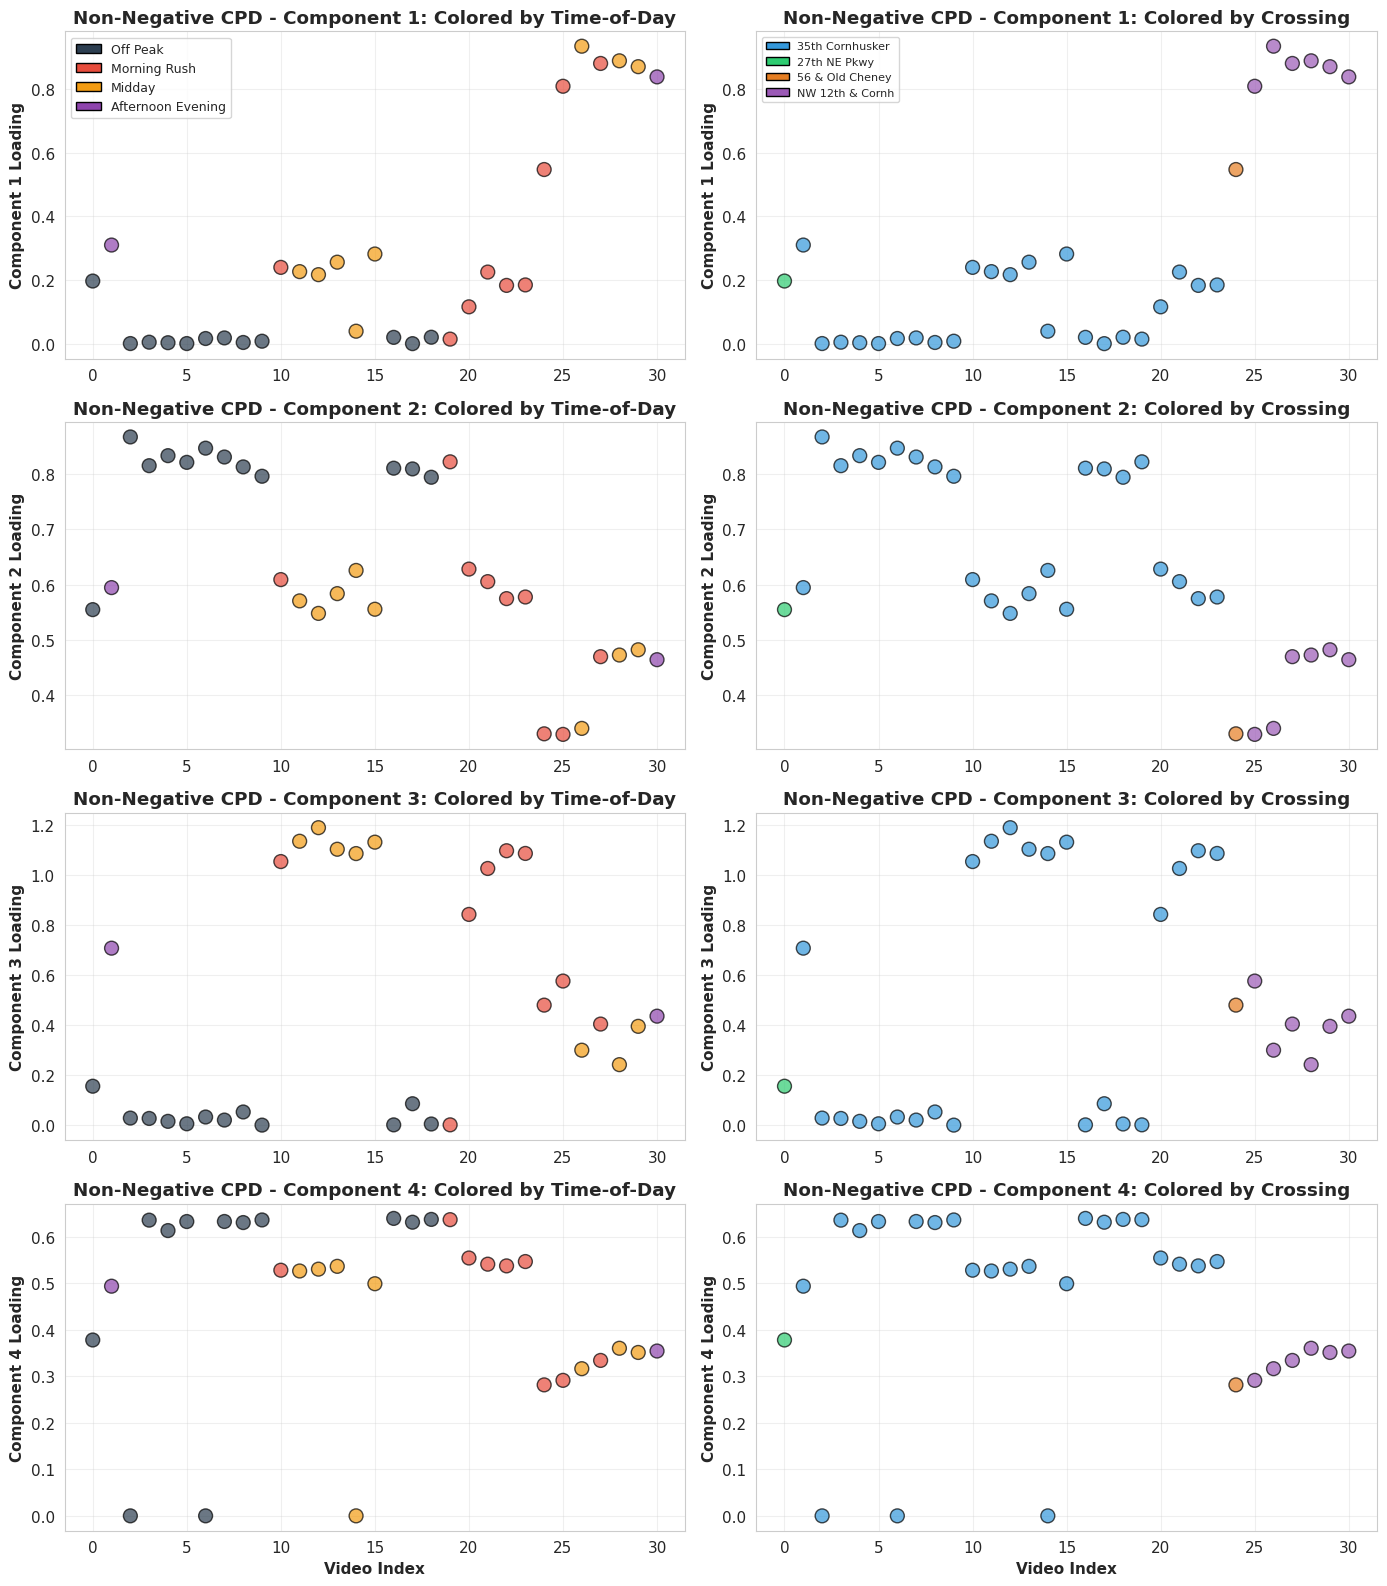


Saved: data/nonnegative_cpd_components_rank4.png


In [24]:
# Visualize non-negative CPD components (Rank 4)
rank = 4
U_nn = results_nn[rank]['U']
lambdas_nn = results_nn[rank]['lambdas']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for comp_idx in range(rank):
    # Left column: Color by time-of-day
    ax_left = axes[comp_idx, 0]
    ax_left.scatter(range(n_videos), U_nn[:, comp_idx], 
                   c=time_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
    ax_left.set_ylabel(f'Component {comp_idx+1} Loading', fontweight='bold')
    ax_left.set_title(f'Non-Negative CPD - Component {comp_idx+1}: Colored by Time-of-Day', fontweight='bold')
    ax_left.grid(True, alpha=0.3)
    
    if comp_idx == rank - 1:
        ax_left.set_xlabel('Video Index', fontweight='bold')
    
    # Add legend for first row
    if comp_idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, edgecolor='black', label=label.replace('_', ' ').title())
                          for label, color in time_color_map.items()]
        ax_left.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), fontsize=9)
    
    # Right column: Color by crossing
    ax_right = axes[comp_idx, 1]
    ax_right.scatter(range(n_videos), U_nn[:, comp_idx],
                    c=crossing_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
    ax_right.set_ylabel(f'Component {comp_idx+1} Loading', fontweight='bold')
    ax_right.set_title(f'Non-Negative CPD - Component {comp_idx+1}: Colored by Crossing', fontweight='bold')
    ax_right.grid(True, alpha=0.3)
    
    if comp_idx == rank - 1:
        ax_right.set_xlabel('Video Index', fontweight='bold')
    
    # Add legend for first row
    if comp_idx == 0:
        legend_elements = [Patch(facecolor=color, edgecolor='black', 
                                label=label.replace('and ', '').replace('Hwy', '').strip()[:15])
                          for label, color in crossing_color_map.items()]
        ax_right.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'nonnegative_cpd_components_rank4.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: data/nonnegative_cpd_components_rank4.png")

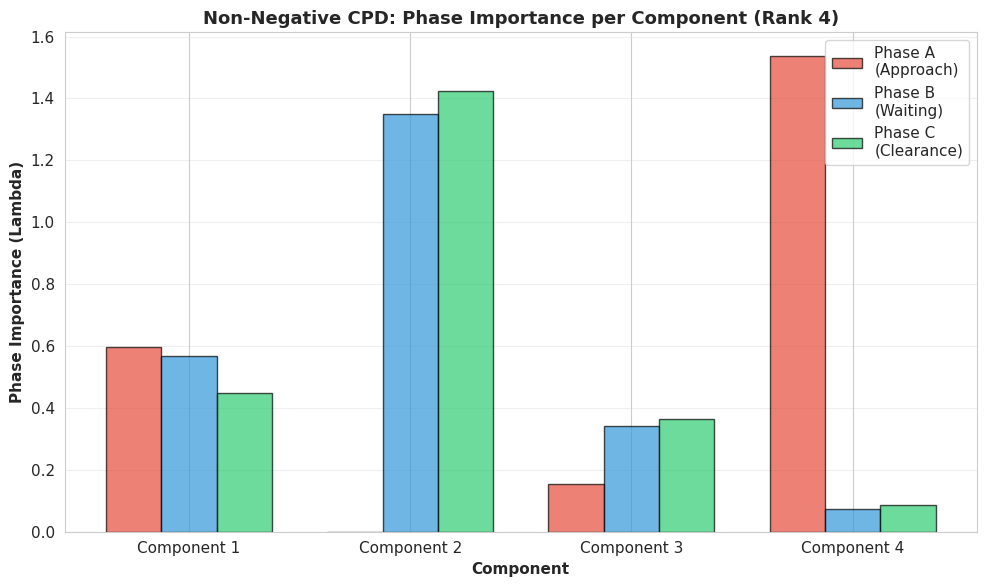


Saved: data/nonnegative_phase_importance_rank4.png


In [25]:
# Analyze non-negative phase importance
rank = 4
lambdas_nn = results_nn[rank]['lambdas']

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(rank)
width = 0.25
phase_names_short = ['Phase A\n(Approach)', 'Phase B\n(Waiting)', 'Phase C\n(Clearance)']
colors_phases = ['#E74C3C', '#3498DB', '#2ECC71']

for phase_idx, (phase_name, color) in enumerate(zip(phase_names_short, colors_phases)):
    offset = width * (phase_idx - 1)
    ax.bar(x + offset, lambdas_nn[phase_idx, :], width, 
           label=phase_name, color=color, alpha=0.7, edgecolor='black')

ax.set_ylabel('Phase Importance (Lambda)', fontweight='bold')
ax.set_xlabel('Component', fontweight='bold')
ax.set_title('Non-Negative CPD: Phase Importance per Component (Rank 4)', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'Component {i+1}' for i in range(rank)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DATA_DIR / 'nonnegative_phase_importance_rank4.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: data/nonnegative_phase_importance_rank4.png")

In [26]:
# Print non-negative interpretation summary
rank = 4
U_nn = results_nn[rank]['U']
lambdas_nn = results_nn[rank]['lambdas']

print("\n" + "="*70)
print("NON-NEGATIVE CPD INTERPRETATION SUMMARY (Rank 4)")
print("="*70)

for comp_idx in range(rank):
    print(f"\nComponent {comp_idx + 1}:")
    print("-" * 40)
    
    # Phase importance
    print("\nPhase Importance:")
    phase_names_simple = ['Phase A (Approach)', 'Phase B (Waiting)', 'Phase C (Clearance)']
    for phase_idx, phase_name in enumerate(phase_names_simple):
        print(f"  {phase_name:25s}: {lambdas_nn[phase_idx, comp_idx]:.3f}")
    
    # Dominant phase
    dominant_phase_idx = np.argmax(lambdas_nn[:, comp_idx])
    print(f"\n  -> Dominant phase: {phase_names_simple[dominant_phase_idx]}")
    
    # Top 5 videos with highest loadings
    top_indices = np.argsort(U_nn[:, comp_idx])[-5:][::-1]
    print(f"\nTop 5 videos with highest loadings:")
    for rank_pos, video_idx in enumerate(top_indices, 1):
        video = video_metadata[video_idx]
        loading = U_nn[video_idx, comp_idx]
        print(f"  {rank_pos}. [{video['time_of_day']:20s}] {video['crossing']:30s} (loading: {loading:.3f})")
    
    # Bottom 5 videos with lowest loadings
    bottom_indices = np.argsort(U_nn[:, comp_idx])[:5]
    print(f"\nBottom 5 videos with lowest loadings:")
    for rank_pos, video_idx in enumerate(bottom_indices, 1):
        video = video_metadata[video_idx]
        loading = U_nn[video_idx, comp_idx]
        print(f"  {rank_pos}. [{video['time_of_day']:20s}] {video['crossing']:30s} (loading: {loading:.3f})")

print("\n" + "="*70)


NON-NEGATIVE CPD INTERPRETATION SUMMARY (Rank 4)

Component 1:
----------------------------------------

Phase Importance:
  Phase A (Approach)       : 0.597
  Phase B (Waiting)        : 0.568
  Phase C (Clearance)      : 0.448

  -> Dominant phase: Phase A (Approach)

Top 5 videos with highest loadings:
  1. [midday              ] NW 12th & Cornhusker           (loading: 0.935)
  2. [midday              ] NW 12th & Cornhusker           (loading: 0.889)
  3. [morning_rush        ] NW 12th & Cornhusker           (loading: 0.880)
  4. [midday              ] NW 12th & Cornhusker           (loading: 0.870)
  5. [afternoon_evening   ] NW 12th & Cornhusker           (loading: 0.838)

Bottom 5 videos with lowest loadings:
  1. [off_peak            ] 35th and Cornhusker Hwy        (loading: 0.001)
  2. [off_peak            ] 35th and Cornhusker Hwy        (loading: 0.001)
  3. [off_peak            ] 35th and Cornhusker Hwy        (loading: 0.001)
  4. [off_peak            ] 35th and Cornhuske

### Side-by-Side Comparison: Standard vs Non-Negative CPD

Let's compare the two approaches for Component 3 (which captures crossing-specific patterns):

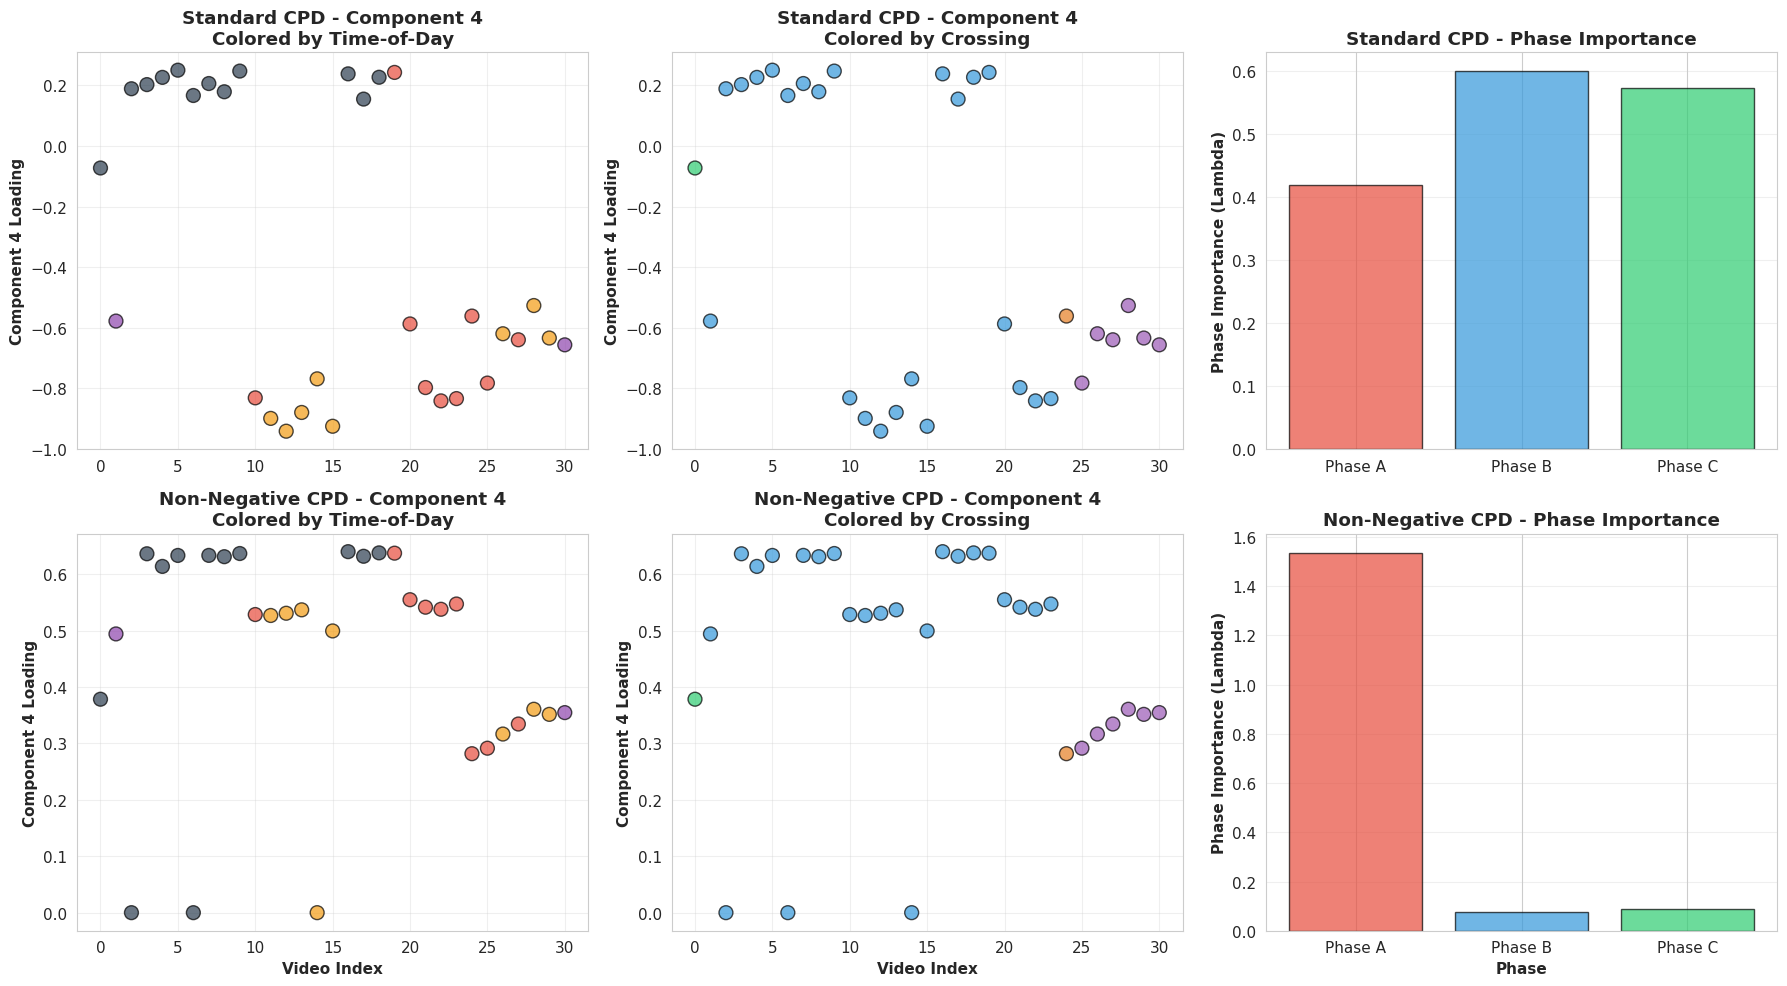

In [27]:
# Compare Standard CPD vs Non-Negative CPD (Component 4)
rank = 4
comp_idx = 3  # Component 4 (0-indexed)

U_standard = results[rank]['U']
lambdas_standard = results[rank]['lambdas']
U_nn = results_nn[rank]['U']
lambdas_nn = results_nn[rank]['lambdas']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: Standard CPD
ax_time = axes[0, 0]
ax_time.scatter(range(n_videos), U_standard[:, comp_idx], 
               c=time_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
ax_time.set_ylabel(f'Component 4 Loading', fontweight='bold')
ax_time.set_title(f'Standard CPD - Component 4\nColored by Time-of-Day', fontweight='bold')
ax_time.grid(True, alpha=0.3)

ax_crossing = axes[0, 1]
ax_crossing.scatter(range(n_videos), U_standard[:, comp_idx],
                   c=crossing_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
ax_crossing.set_ylabel(f'Component 4 Loading', fontweight='bold')
ax_crossing.set_title(f'Standard CPD - Component 4\nColored by Crossing', fontweight='bold')
ax_crossing.grid(True, alpha=0.3)

ax_phase = axes[0, 2]
x = np.arange(3)
width = 0.8
phase_names_short = ['Phase A', 'Phase B', 'Phase C']
colors_phases = ['#E74C3C', '#3498DB', '#2ECC71']
bars = ax_phase.bar(x, lambdas_standard[:, comp_idx], width, 
                    color=colors_phases, alpha=0.7, edgecolor='black')
ax_phase.set_ylabel('Phase Importance (Lambda)', fontweight='bold')
ax_phase.set_title('Standard CPD - Phase Importance', fontweight='bold')
ax_phase.set_xticks(x)
ax_phase.set_xticklabels(phase_names_short)
ax_phase.grid(True, alpha=0.3, axis='y')

# Bottom row: Non-Negative CPD
ax_time = axes[1, 0]
ax_time.scatter(range(n_videos), U_nn[:, comp_idx], 
               c=time_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
ax_time.set_ylabel(f'Component 4 Loading', fontweight='bold')
ax_time.set_title(f'Non-Negative CPD - Component 4\nColored by Time-of-Day', fontweight='bold')
ax_time.grid(True, alpha=0.3)
ax_time.set_xlabel('Video Index', fontweight='bold')

ax_crossing = axes[1, 1]
ax_crossing.scatter(range(n_videos), U_nn[:, comp_idx],
                   c=crossing_colors, s=100, alpha=0.7, edgecolors='black', linewidths=1)
ax_crossing.set_ylabel(f'Component 4 Loading', fontweight='bold')
ax_crossing.set_title(f'Non-Negative CPD - Component 4\nColored by Crossing', fontweight='bold')
ax_crossing.grid(True, alpha=0.3)
ax_crossing.set_xlabel('Video Index', fontweight='bold')

ax_phase = axes[1, 2]
bars = ax_phase.bar(x, lambdas_nn[:, comp_idx], width, 
                    color=colors_phases, alpha=0.7, edgecolor='black')
ax_phase.set_ylabel('Phase Importance (Lambda)', fontweight='bold')
ax_phase.set_title('Non-Negative CPD - Phase Importance', fontweight='bold')
ax_phase.set_xticks(x)
ax_phase.set_xticklabels(phase_names_short)
ax_phase.grid(True, alpha=0.3, axis='y')
ax_phase.set_xlabel('Phase', fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_DIR / 'cpd_comparison_standard_vs_nonnegative.png', dpi=150, bbox_inches='tight')
plt.show()